In [ ]:
import os, json, time
from openai import OpenAI
import pandas as pd
from pathlib import Path

ROOT = Path(r"D:/patent recentive")
OUT  = ROOT / "outputs"
for sub in ["intermediate", "scores", "figures", "tables", "logs"]:
    (OUT / sub).mkdir(exist_ok=True, parents=True)

DEEPSEEK_API_KEY = "sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"


client = OpenAI(
    api_key=DEEPSEEK_API_KEY,
    base_url="https://api.deepseek.com"
)

PROMPT = """You are a patent attorney applying the Federal Circuit's two-step Alice test as articulated in Recentive Analytics, Inc. v. Fox Corp. (Fed. Cir. 2025).

The Federal Circuit ruled that claims which "do no more than apply established methods of machine learning to a new data environment, without disclosing improvements to the machine learning models to be applied," are ineligible under 35 U.S.C. §101. Features that are "incident to the very nature of machine learning" — such as iterative training or dynamic updating — do NOT supply the inventive concept required at Alice step two.

A claim resembles Recentive-vulnerable language to the extent that it applies established machine learning techniques to a new data environment without disclosing a specific technological improvement to the model itself (a new architecture, new loss function, new training procedure, new representation, or new sampling method).

Read the patent claim below and output ONLY a JSON object with these exact fields:
- "score": a float from 0.00 to 1.00 reflecting textual resemblance to Recentive-vulnerable claim language. Anchors: 0.00 = the claim clearly recites a technological improvement to the model itself (low resemblance to Recentive-vulnerable claims); 0.50 = mixed or ambiguous; 1.00 = the claim clearly applies established ML to a new data environment, business problem, or domain without disclosing model-level improvement (high resemblance to Recentive-vulnerable claims).
- "confidence": one of "low", "medium", "high"
- "justification": ONE sentence quoting the specific claim language that drove your decision

Patent claim:
{claim_text}
"""

def score_patent(claim_text, model="deepseek-chat", max_chars=8000):
    """Score one patent's claim text. Returns (parsed_json, usage_dict)."""
    text_to_send = (claim_text or "")[:max_chars]
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": PROMPT.format(claim_text=text_to_send)}],
        temperature=0.0,
        max_tokens=300,
        response_format={"type": "json_object"},
    )
    raw = response.choices[0].message.content
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        parsed = {"score": None, "confidence": "low",
                  "justification": f"parse_error: {raw[:200]}"}
    usage = {
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
    }
    return parsed, usage

# ---------- Smoke test on one patent from scoring_table ----------
scoring = pd.read_parquet(OUT / "intermediate" / "scoring_table.parquet")
print(f"Scoring table size: {len(scoring):,}")

test_row = scoring.iloc[0]
print(f"\nTest patent: {test_row['patent_id']}  ({test_row['assignee_org']}, {test_row['grant_year']})")
print(f"Claim text (first 400 chars):\n  {test_row['claim_text_clean'][:400]}...\n")

t0 = time.time()
result, usage = score_patent(test_row['claim_text_clean'])
elapsed = time.time() - t0

print(f"=== DeepSeek response ===")
print(json.dumps(result, indent=2, ensure_ascii=False))
print(f"\nTokens used: {usage['prompt_tokens']} in + {usage['completion_tokens']} out")
print(f"Time:        {elapsed:.2f}s")
print(f"Approx cost: ~${usage['prompt_tokens']/1e6 * 0.27 + usage['completion_tokens']/1e6 * 1.10:.5f}")

Scoring table size: 76,463

Test patent: 10001838  (Amazon Technologies, Inc., 2018)
Claim text (first 400 chars):
  A computer-implemented method, comprising: capturing image information using a sensor associated with a computing device; receiving a first input, the first input representing the beginning of a period of time for determining motion information; determining, from the image information and within the period of time, the motion information, the motion information associated with a feature of a user ...

=== DeepSeek response ===
{
  "score": 0.85,
  "confidence": "high",
  "justification": "The claim applies established motion tracking and keyboard mapping techniques to a new data environment (gesture-based typing without contact) without disclosing any improvement to the underlying machine learning models."
}

Tokens used: 576 in + 59 out
Time:        6.70s
Approx cost: ~$0.00022


In [ ]:
def load_claim_text_for(patent_ids):
    """Fetch claim_sequence==0 text for any patent_ids from PatentsView g_claims."""
    pids = [str(p) for p in patent_ids]
    pid_set = set(pids)

    # Find their grant years from master so we know which g_claims_YYYY to open
    master = pd.read_parquet(OUT / "intermediate" / "patent_firm_master.parquet")
    target = master[master["patent_id"].isin(pids)][["patent_id", "grant_date", "predict50_any_ai", "predict50_ml", "ai_score_ml"]].copy()
    if len(target) == 0:
        print(f"WARNING: none of {patent_ids} found in master")
        return pd.DataFrame()
    target["grant_year"] = target["grant_date"].dt.year
    years_needed = sorted(set(target["grant_year"].dropna().astype(int)))
    print(f"Patents found in master: {len(target)}/{len(pids)}, years needed: {years_needed}")

    pieces = []
    for year in years_needed:
        fkey = f"g_claims_{year}"
        if fkey not in FILES:
            continue
        df = pd.read_csv(ROOT / FILES[fkey], sep="\t", compression="zip",
                         usecols=["patent_id", "claim_sequence", "claim_text"],
                         dtype={"patent_id": "str"}, low_memory=False)
        df["patent_id"] = df["patent_id"].astype(str).str.strip()
        df = df[(df["claim_sequence"] == 0) & (df["patent_id"].isin(pid_set))]
        pieces.append(df)

    if not pieces:
        return pd.DataFrame()
    out = pd.concat(pieces, ignore_index=True)
    out["claim_text_clean"] = (out["claim_text"]
                                .astype(str)
                                .str.replace(r"^\s*1\.\s*", "", regex=True)
                                .str.strip())
    out = out.drop_duplicates(subset=["patent_id"], keep="first")
    out = out.merge(target[["patent_id", "grant_year", "predict50_any_ai", "predict50_ml", "ai_score_ml"]],
                    on="patent_id", how="left")
    return out

# Recentive's four litigated patents
recentive_pids = ["10911811", "10958957", "11386367", "11537960"]

print("Loading claim text for the four Recentive patents...")
recentive_claims = load_claim_text_for(recentive_pids)
print(f"\nLoaded {len(recentive_claims)} claim records")
print(recentive_claims[["patent_id", "grant_year", "predict50_any_ai", "predict50_ml", "ai_score_ml"]].to_string(index=False))

Loading claim text for the four Recentive patents...
Patents found in master: 4/4, years needed: [2021, 2022]

Loaded 4 claim records
patent_id  grant_year  predict50_any_ai  predict50_ml  ai_score_ml
 10911811        2021                 1             1     0.878133
 10958957        2021                 1             0     0.122904
 11386367        2022                 1             0     0.272074
 11537960        2022                 1             0     0.417846


In [ ]:
print("="*70)
print("Recentive patents sanity check")
print("="*70)

results = []
for _, row in recentive_claims.iterrows():
    print(f"\n--- Patent {row['patent_id']} (granted {row['grant_year']}) ---")
    print(f"  Claim (first 250 chars): {row['claim_text_clean'][:250]}...")
    t0 = time.time()
    out, usage = score_patent(row["claim_text_clean"])
    elapsed = time.time() - t0
    print(f"  → score:         {out.get('score')}")
    print(f"  → confidence:    {out.get('confidence')}")
    print(f"  → justification: {out.get('justification')}")
    print(f"  ({elapsed:.1f}s, {usage['prompt_tokens']} in + {usage['completion_tokens']} out tokens)")
    results.append({"patent_id": row["patent_id"], **out, **usage})

recentive_results = pd.DataFrame(results)
print("\n" + "="*70)
print("SUMMARY:")
print("="*70)
print(recentive_results[["patent_id", "score", "confidence"]].to_string(index=False))
print(f"\nMean score: {recentive_results['score'].mean():.3f}")
print(f"Min score:  {recentive_results['score'].min():.3f}")

if recentive_results["score"].mean() >= 0.7:
    print("\n✓ PASS: All four Recentive patents score high, as predicted.")
elif recentive_results["score"].mean() >= 0.5:
    print("\n△ PARTIAL: Average score above 0.5 but below 0.7. Prompt may need tuning.")
else:
    print("\n✗ FAIL: Recentive patents not flagged as high-vulnerability. Investigate.")

# Save for the working paper appendix
recentive_results.to_csv(OUT / "scores" / "recentive_benchmark.csv", index=False)

Recentive patents sanity check

--- Patent 10911811 (granted 2021) ---
  Claim (first 250 chars): A computer-implemented method for dynamically generating a network map, the method comprising: receiving a schedule for a first plurality of live events scheduled to start at a first time and a second plurality of live events scheduled to start at a ...
  → score:         0.85
  → confidence:    high
  → justification: The claim recites 'using a machine learning technique to optimize an overall television rating' without specifying any improvement to the machine learning model itself, merely applying established ML to a new data environment (scheduling live events).
  (4.6s, 669 in + 68 out tokens)

--- Patent 10958957 (granted 2021) ---
  Claim (first 250 chars): A computer-implemented method for dynamically generating a network map, the method comprising: obtaining a schedule for a first plurality of events scheduled to start at a first time and a second plurality of events scheduled to 

In [ ]:
SAMPLE_SIZE = 5000
SEED = 20250510

# Re-stratify
year_sizes = scoring['grant_year'].value_counts().sort_index()
year_alloc = (year_sizes / year_sizes.sum() * SAMPLE_SIZE).round().astype(int)
diff = SAMPLE_SIZE - year_alloc.sum()
if diff != 0:
    year_alloc[year_alloc.idxmax()] += diff

# Already-scored 1000 patents will be reused
existing_pids = set(pd.read_parquet(OUT / "intermediate" / "pilot_sample_1000.parquet")
                    ["patent_id"].astype(str))

# Need 4000 NEW patents
samples = []
for year, target_n in year_alloc.items():
    pool = scoring[(scoring['grant_year'] == year)
                    & ~scoring['patent_id'].astype(str).isin(existing_pids)]
    # Already have some from 1000 sample; how many more needed
    have = (sample_df['grant_year']==year).sum() if 'sample_df' in dir() else 0
    n_needed = target_n - have
    if n_needed > 0 and len(pool) >= n_needed:
        samples.append(pool.sample(n=n_needed, random_state=SEED + int(year)))

new_sample = pd.concat(samples).reset_index(drop=True)
print(f"New patents to score: {len(new_sample)}")

# Combine with original
sample_df_5k = pd.concat([
    pd.read_parquet(OUT / "intermediate" / "pilot_sample_1000.parquet"),
    new_sample
]).drop_duplicates(subset="patent_id").reset_index(drop=True)
print(f"Total 5000 sample: {len(sample_df_5k)}")
sample_df_5k.to_parquet(OUT / "intermediate" / "pilot_sample_5000.parquet")

# Run R1 on the new patents only (existing scores preserved in pilot_scores_r1.csv)
SCORES_R1_FILE = OUT / "scores" / "pilot_scores_r1.csv"
existing_scores = pd.read_csv(SCORES_R1_FILE)
done_ids = set(existing_scores['patent_id'].astype(str))

remaining = sample_df_5k[~sample_df_5k['patent_id'].astype(str).isin(done_ids)]
print(f"Remaining to score: {len(remaining):,}  (existing {len(done_ids):,} preserved)")
print(f"Expected time: ~{len(remaining) * 8 / 8 / 60:.0f} min")
print(f"Expected cost: ~${len(remaining) * 0.0037:.2f}")

# Run with same threading code as before — paste the lock + score_one_r1 + ThreadPoolExecutor block
import threading
lock = threading.Lock()

def score_one_r1(row):
    pid = str(row['patent_id'])
    try:
        t0 = time.time()
        result, usage = score_patent_r1(row['claim_text_clean'])
        out_row = {'patent_id': pid, 'score': result.get('score'),
                   'confidence': result.get('confidence'),
                   'justification': str(result.get('justification', ''))[:500],
                   'tokens_in': usage['prompt_tokens'],
                   'tokens_out': usage['completion_tokens'],
                   'elapsed': round(time.time()-t0, 2)}
    except Exception as e:
        out_row = {'patent_id': pid, 'score': None, 'confidence': 'error',
                   'justification': f"error: {str(e)[:200]}",
                   'tokens_in': 0, 'tokens_out': 0, 'elapsed': 0}
    with lock:
        pd.DataFrame([out_row]).to_csv(SCORES_R1_FILE, mode='a',
                                        header=False, index=False)
    return out_row

t_start = time.time()
completed = 0
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(score_one_r1, row) for _, row in remaining.iterrows()]
    for f in as_completed(futures):
        completed += 1
        if completed % 100 == 0:
            el = time.time() - t_start
            rate = completed / el
            eta = (len(remaining) - completed) / rate / 60
            print(f"  {completed}/{len(remaining)}  ({rate:.2f}/s, ETA {eta:.1f}m)")

print(f"\nDone in {(time.time()-t_start)/60:.1f} min")

New patents to score: 4000
Total 5000 sample: 5000
Remaining to score: 4,000  (existing 1,000 preserved)
Expected time: ~67 min
Expected cost: ~$14.80
  100/4000  (1.27/s, ETA 51.2m)
  200/4000  (1.24/s, ETA 51.0m)
  300/4000  (1.26/s, ETA 49.0m)
  400/4000  (1.26/s, ETA 47.6m)
  500/4000  (1.27/s, ETA 45.8m)
  600/4000  (1.30/s, ETA 43.7m)
  700/4000  (1.30/s, ETA 42.4m)
  800/4000  (1.30/s, ETA 41.1m)
  900/4000  (1.30/s, ETA 39.7m)
  1000/4000  (1.30/s, ETA 38.3m)
  1100/4000  (1.31/s, ETA 37.0m)
  1200/4000  (1.31/s, ETA 35.6m)
  1300/4000  (1.32/s, ETA 34.1m)
  1400/4000  (1.32/s, ETA 32.8m)
  1500/4000  (1.32/s, ETA 31.5m)
  1600/4000  (1.34/s, ETA 29.9m)
  1700/4000  (1.35/s, ETA 28.4m)
  1800/4000  (1.35/s, ETA 27.1m)
  1900/4000  (1.36/s, ETA 25.8m)
  2000/4000  (1.36/s, ETA 24.4m)
  2100/4000  (1.37/s, ETA 23.1m)
  2200/4000  (1.38/s, ETA 21.8m)
  2300/4000  (1.38/s, ETA 20.5m)
  2400/4000  (1.39/s, ETA 19.2m)
  2500/4000  (1.40/s, ETA 17.9m)
  2600/4000  (1.41/s, ETA 16.6m)


5K merged: 4,970 patents with R1 scores

Firms with at least 1 patent in 5K sample: 381
Firms with 5+ patents: 125
Firms with 10+ patents: 67

Vulnerability distribution (firm-level):
count    381.000000
mean       0.712116
std        0.292480
min        0.000000
25%        0.575000
50%        0.838889
75%        0.950000
max        1.000000


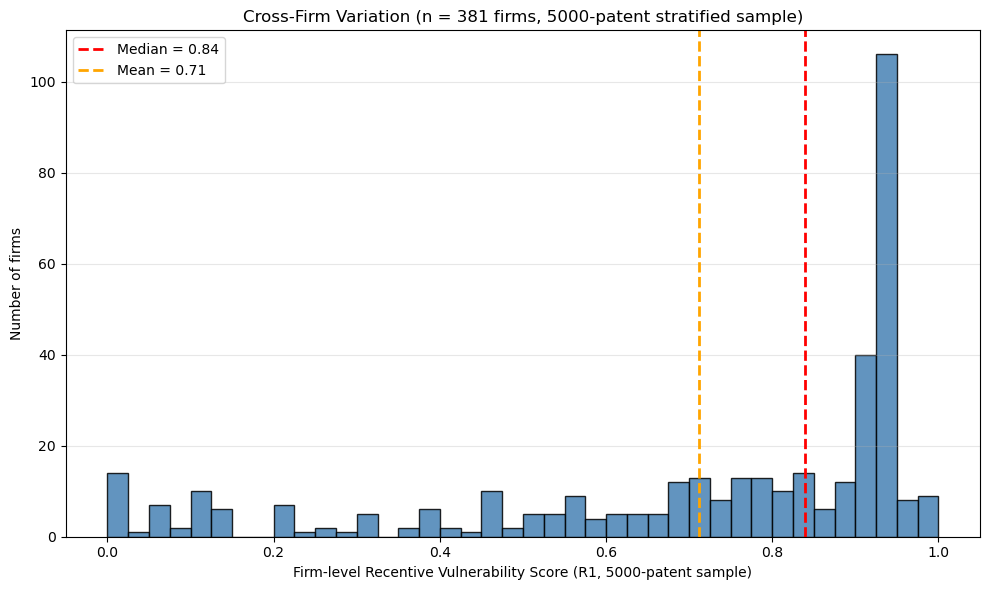


Firms with 5+ patents in 5K sample: 125

Top 15 highest-vulnerability:
                                   org  n_patents  vulnerability
                Wells Fargo Bank, N.A.         18       0.958333
                       Pinterest, Inc.          6       0.958333
         Applied Materials Israel Ltd.          7       0.950000
                  Electronic Arts Inc.          7       0.950000
                       EMC Corporation          9       0.944444
                   Chevron U.S.A. Inc.          8       0.943750
                 WAL-MART STORES, INC.          6       0.941667
                             NICE LTD.         10       0.940000
                     FANUC CORPORATION          9       0.938889
                         Kyndryl, Inc.          7       0.935714
                    T-Mobile USA, Inc.          6       0.933333
            Allstate Insurance Company         11       0.931818
Rockwell Automation Technologies, Inc.          5       0.930000
       HARTFORD FI

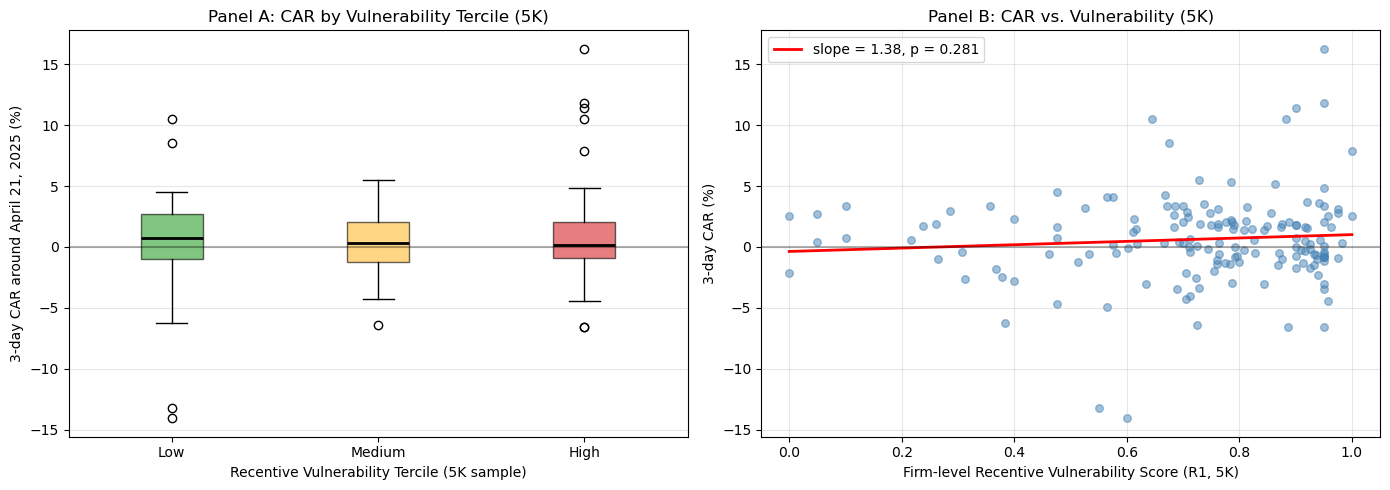


Saved Figure 3 (5K) and CAR analysis CSV.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

sample_5k = pd.read_parquet(OUT / "intermediate" / "pilot_sample_5000.parquet")
r1 = pd.read_csv(OUT / "scores" / "pilot_scores_r1.csv")
r1["score"] = pd.to_numeric(r1["score"], errors="coerce")
r1["patent_id"] = r1["patent_id"].astype(str)
r1 = r1[r1["score"].notna()]
sample_5k["patent_id"] = sample_5k["patent_id"].astype(str)

merged = sample_5k.merge(r1[["patent_id","score"]], on="patent_id", how="inner")
print(f"5K merged: {len(merged):,} patents with R1 scores")

firm_5k = (merged.groupby("gvkey")
           .agg(n_patents=("patent_id","count"),
                vulnerability=("score","mean"),
                org=("assignee_org","first"))
           .reset_index())
firm_5k.to_parquet(OUT / "intermediate" / "firm_vulnerability_r1_5k.parquet")

print(f"\nFirms with at least 1 patent in 5K sample: {len(firm_5k)}")
print(f"Firms with 5+ patents: {(firm_5k['n_patents']>=5).sum()}")
print(f"Firms with 10+ patents: {(firm_5k['n_patents']>=10).sum()}")
print(f"\nVulnerability distribution (firm-level):")
print(firm_5k["vulnerability"].describe().to_string())


fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(firm_5k["vulnerability"], bins=40, color="steelblue",
        edgecolor="black", alpha=0.85)
ax.axvline(firm_5k["vulnerability"].median(), color="red", linestyle="--",
           linewidth=2, label=f"Median = {firm_5k['vulnerability'].median():.2f}")
ax.axvline(firm_5k["vulnerability"].mean(), color="orange", linestyle="--",
           linewidth=2, label=f"Mean = {firm_5k['vulnerability'].mean():.2f}")
ax.set_xlabel("Firm-level Recentive Vulnerability Score (R1, 5000-patent sample)")
ax.set_ylabel("Number of firms")
ax.set_title(f"Cross-Firm Variation (n = {len(firm_5k)} firms, 5000-patent stratified sample)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "figures" / "fig2_firm_distribution_5k.png", dpi=300, bbox_inches="tight")
plt.show()


firm_credible = firm_5k[firm_5k["n_patents"] >= 5].copy()
print(f"\nFirms with 5+ patents in 5K sample: {len(firm_credible)}")
print("\nTop 15 highest-vulnerability:")
print(firm_credible.nlargest(15, "vulnerability")
      [["org","n_patents","vulnerability"]].to_string(index=False))
print("\nBottom 15 lowest-vulnerability:")
print(firm_credible.nsmallest(15, "vulnerability")
      [["org","n_patents","vulnerability"]].to_string(index=False))

firm_tic = pd.read_csv(OUT / "intermediate" / "firm_tickers_for_yfinance.csv")
firm_tic = firm_tic.drop(columns=["vulnerability","n_patents"], errors="ignore")
firm_tic["gvkey"] = firm_tic["gvkey"].astype(int)
firm_5k["gvkey"] = firm_5k["gvkey"].astype(int)
firm_tic = firm_tic.merge(firm_5k[["gvkey","vulnerability","n_patents"]],
                            on="gvkey", how="left")
firm_tic = firm_tic.dropna(subset=["vulnerability","tic"])
print(f"\nFirms with ticker + 5K Vulnerability: {len(firm_tic)}")

# Load yfinance prices and FF
prices_long = pd.read_csv(ROOT / "yfinance_prices_2024_2025.csv")
prices_long["Date"] = pd.to_datetime(prices_long["Date"])
prices = prices_long.pivot(index="Date", columns="tic", values="close").sort_index()
returns = prices.pct_change().dropna(how="all")
ff = pd.read_csv(ROOT / "ff_factors_daily.csv", parse_dates=["date"]).set_index("date")

# Filter to firms with usable data
firm_tic["has_data"] = firm_tic["tic"].apply(
    lambda t: t in returns.columns and returns[t].notna().sum() > 100)
firm_tic = firm_tic[firm_tic["has_data"]].copy()
print(f"After yfinance filter: {len(firm_tic)} firms")

# Estimate betas
beta_window = returns.loc["2025-01-02":"2025-03-31"]
ff_b = ff.loc["2025-01-02":"2025-03-31"]
common = beta_window.index.intersection(ff_b.index)
mkt_e = ff_b.loc[common, "Mkt-RF"]
rf_e = ff_b.loc[common, "RF"]

betas, alphas = {}, {}
for tic in firm_tic["tic"]:
    if tic not in beta_window.columns: continue
    s = beta_window.loc[common, tic].dropna()
    if len(s) < 30: continue
    excess = s - rf_e.loc[s.index]
    excess_mkt = mkt_e.loc[s.index]
    slope, intercept, *_ = stats.linregress(excess_mkt.values, excess.values)
    betas[tic] = slope; alphas[tic] = intercept

# Compute CAR over [-1,+1]
ev_ret = returns.loc["2025-04-17":"2025-04-22"]
ev_ff = ff.loc["2025-04-17":"2025-04-22"]
common_ev = ev_ret.index.intersection(ev_ff.index)

cars = []
for tic in firm_tic["tic"]:
    if tic not in betas or tic not in ev_ret.columns: continue
    s = ev_ret.loc[common_ev, tic].dropna()
    if len(s) < 2: continue
    mkt = ev_ff.loc[s.index, "Mkt-RF"]
    rf = ev_ff.loc[s.index, "RF"]
    expected = rf + alphas[tic] + betas[tic] * mkt
    cars.append({"tic": tic, "CAR": (s - expected).sum()})

car_df = pd.DataFrame(cars)
analysis_5k = firm_tic.merge(car_df, on="tic", how="inner")
print(f"\nFinal CAR sample with 5K Vulnerability: {len(analysis_5k)} firms")

# Tercile + continuous + median split
analysis_5k["vuln_tercile"] = pd.qcut(analysis_5k["vulnerability"], q=3,
                                        labels=["Low","Medium","High"], duplicates="drop")

print("\n" + "="*70)
print("CAR by Vulnerability Tercile (5K sample)")
print("="*70)
print(analysis_5k.groupby("vuln_tercile")["CAR"].agg(["mean","median","std","count"]))

high = analysis_5k[analysis_5k["vuln_tercile"]=="High"]["CAR"].dropna()
low  = analysis_5k[analysis_5k["vuln_tercile"]=="Low"]["CAR"].dropna()
t, p = stats.ttest_ind(high, low, equal_var=False)
print(f"\nWelch t (High vs Low): diff={(high.mean()-low.mean())*100:.2f}%, "
      f"t={t:.2f}, p={p:.3f}, n_high={len(high)}, n_low={len(low)}")

# Continuous OLS
slope, intercept, r, p_reg, se = stats.linregress(
    analysis_5k["vulnerability"], analysis_5k["CAR"]*100)
print(f"\nOLS continuous: slope={slope:.3f} (SE {se:.3f}), p={p_reg:.4f}, n={len(analysis_5k)}")

# Median split
above = analysis_5k[analysis_5k["vulnerability"] > analysis_5k["vulnerability"].median()]["CAR"]
below = analysis_5k[analysis_5k["vulnerability"] <= analysis_5k["vulnerability"].median()]["CAR"]
t_m, p_m = stats.ttest_ind(above, below, equal_var=False)
print(f"\nMedian split: above={above.mean()*100:.2f}%, below={below.mean()*100:.2f}%, "
      f"diff={(above.mean()-below.mean())*100:.2f}%, p={p_m:.3f}")

# Restrict to 5+ patent firms (cleaner Vulnerability)
clean = analysis_5k[analysis_5k["n_patents"] >= 5].copy()
print(f"\n5+ patent firms in CAR sample: {len(clean)}")
if len(clean) > 30:
    slope_c, intercept_c, _, p_c, se_c = stats.linregress(
        clean["vulnerability"], clean["CAR"]*100)
    print(f"  OLS: slope={slope_c:.3f} (SE {se_c:.3f}), p={p_c:.4f}, n={len(clean)}")

# Multiple windows
print("\n" + "="*70)
print("Robustness: alternative event windows (5K Vulnerability)")
print("="*70)
windows = {
    "[0, 0]":   ("2025-04-21", "2025-04-21"),
    "[-1, +1]": ("2025-04-17", "2025-04-22"),
    "[-1, +3]": ("2025-04-17", "2025-04-24"),
    "[-3, +3]": ("2025-04-15", "2025-04-24"),
    "[-1, +5]": ("2025-04-17", "2025-04-28"),
}
for name, (start, end) in windows.items():
    er = returns.loc[start:end]
    eff = ff.loc[start:end]
    cw_common = er.index.intersection(eff.index)
    cars_w = []
    for tic in analysis_5k["tic"]:
        if tic not in betas or tic not in er.columns: continue
        s = er.loc[cw_common, tic].dropna()
        if len(s) < 1: continue
        mkt = eff.loc[s.index, "Mkt-RF"]; rf = eff.loc[s.index, "RF"]
        expected = rf + alphas[tic] + betas[tic] * mkt
        cars_w.append({"tic": tic, "CAR": (s-expected).sum()})
    df_w = pd.DataFrame(cars_w).merge(analysis_5k[["tic","vulnerability"]], on="tic")
    sl, ic, _, pv, sev = stats.linregress(df_w["vulnerability"], df_w["CAR"]*100)
    print(f"  Window {name:10s}: slope={sl:>6.2f} (SE {sev:.2f}), p={pv:.3f}, n={len(df_w)}")

# Plot updated Figure 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
data_for_box = [analysis_5k[analysis_5k["vuln_tercile"]==g]["CAR"].dropna()*100
                for g in ["Low","Medium","High"]]
bp = ax1.boxplot(data_for_box, labels=["Low","Medium","High"],
                 patch_artist=True, medianprops=dict(color="black", linewidth=2))
for patch, c in zip(bp["boxes"], ["#2ca02c","#ffbb33","#d62728"]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax1.axhline(0, color="black", linestyle="-", alpha=0.3)
ax1.set_xlabel("Recentive Vulnerability Tercile (5K sample)")
ax1.set_ylabel("3-day CAR around April 21, 2025 (%)")
ax1.set_title("Panel A: CAR by Vulnerability Tercile (5K)")
ax1.grid(axis="y", alpha=0.3)

ax2.scatter(analysis_5k["vulnerability"], analysis_5k["CAR"]*100,
            alpha=0.5, s=30, color="steelblue")
xs = np.linspace(0, 1, 100)
ax2.plot(xs, intercept + slope*xs, "r-", linewidth=2,
         label=f"slope = {slope:.2f}, p = {p_reg:.3f}")
ax2.axhline(0, color="black", linestyle="-", alpha=0.3)
ax2.set_xlabel("Firm-level Recentive Vulnerability Score (R1, 5K)")
ax2.set_ylabel("3-day CAR (%)")
ax2.set_title("Panel B: CAR vs. Vulnerability (5K)")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "figures" / "fig3_april21_CAR_5k.png", dpi=300, bbox_inches="tight")
plt.show()

analysis_5k.to_csv(OUT / "tables" / "april21_CAR_analysis_5k.csv", index=False)
print(f"\nSaved Figure 3 (5K) and CAR analysis CSV.")

5K merged for Figure 1: 4,970


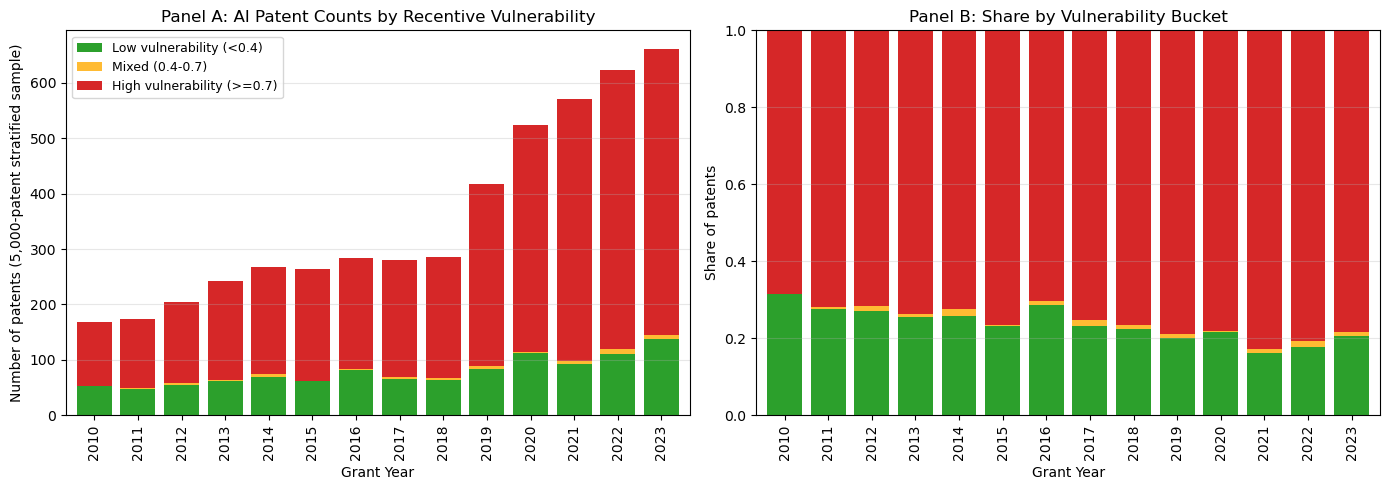

Saved Figure 1 (5K) to D:\patent recentive\outputs\figures\fig1_vulnerability_trend_5k.png

=== Patent-level score distribution (5K sample) ===
count    4970.000000
mean        0.747252
std         0.347270
min         0.000000
25%         0.850000
50%         0.950000
75%         0.950000
max         1.000000

Share in 'High vulnerability' bucket: 77.0%
Share in 'Low vulnerability' bucket:  22.0%


In [ ]:
sample_5k = pd.read_parquet(OUT / "intermediate" / "pilot_sample_5000.parquet")
sample_5k["patent_id"] = sample_5k["patent_id"].astype(str).str.strip()

r1 = pd.read_csv(OUT / "scores" / "pilot_scores_r1.csv")
r1["score"] = pd.to_numeric(r1["score"], errors="coerce")
r1["patent_id"] = r1["patent_id"].astype(str).str.strip()
r1 = r1[r1["score"].notna()]

merged_5k = sample_5k.merge(r1[["patent_id","score"]], on="patent_id", how="inner")
print(f"5K merged for Figure 1: {len(merged_5k):,}")

# Bucket
def bucket(s):
    if s >= 0.7: return "High vulnerability (>=0.7)"
    if s >= 0.4: return "Mixed (0.4-0.7)"
    return "Low vulnerability (<0.4)"
merged_5k["bucket"] = merged_5k["score"].apply(bucket)

counts = (merged_5k.groupby(["grant_year","bucket"]).size()
                    .unstack(fill_value=0))
order = ["Low vulnerability (<0.4)", "Mixed (0.4-0.7)", "High vulnerability (>=0.7)"]
counts = counts[[c for c in order if c in counts.columns]]
shares = counts.div(counts.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2ca02c", "#ffbb33", "#d62728"]

counts.plot(kind="bar", stacked=True, ax=ax1, color=colors, width=0.8)
ax1.set_xlabel("Grant Year")
ax1.set_ylabel("Number of patents (5,000-patent stratified sample)")
ax1.set_title("Panel A: AI Patent Counts by Recentive Vulnerability")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

shares.plot(kind="bar", stacked=True, ax=ax2, color=colors, width=0.8)
ax2.set_xlabel("Grant Year")
ax2.set_ylabel("Share of patents")
ax2.set_title("Panel B: Share by Vulnerability Bucket")
ax2.set_ylim(0, 1)
ax2.legend().set_visible(False)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "figures" / "fig1_vulnerability_trend_5k.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved Figure 1 (5K) to {OUT/'figures'/'fig1_vulnerability_trend_5k.png'}")

# Summary stats for the figure caption
print("\n=== Patent-level score distribution (5K sample) ===")
print(merged_5k["score"].describe().to_string())
print(f"\nShare in 'High vulnerability' bucket: {(merged_5k['score']>=0.7).mean()*100:.1f}%")
print(f"Share in 'Low vulnerability' bucket:  {(merged_5k['score']<0.4).mean()*100:.1f}%")